# Lab 4 — Data Preprocessing, Normalization, Outliers (IQR), and PCA  
**Dataset:** `Chocolate_Sales.csv`  

Maan Alghamdi - 2240001433

## 1) Imports (VERY IMPORTANT) run this cell... then enter the file of the csv i provided in my github

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Chocolate_Sales.csv to Chocolate_Sales.csv


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

# Display tweaks (optional)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)


## 2) Load the dataset

In [4]:
# If your file is in the same folder as this notebook, this will work:
# df = pd.read_csv("Chocolate_Sales.csv")

# In this environment, the dataset is located here:
df = pd.read_csv("Chocolate_Sales.csv")
df.head()


,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   3282 non-null   object
 1   Country        3282 non-null   object
 2   Product        3282 non-null   object
 3   Date           3282 non-null   object
 4   Amount         3282 non-null   object
 5   Boxes Shipped  3282 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 154.0+ KB


In [6]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Sales Person,3282,25,Kelci Walkden,162,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,3282,6,Australia,615,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product,3282,22,Eclairs,180,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,3282,504,13/01/2024,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Amount,3282,3013,"$2,317.00",5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Boxes Shipped,3282.0,NaN,NaN,NaN,164.666971,124.024736,1.0,71.0,137.0,232.0,778.0


##Task 1 — Identify data quality issues

check
- Missing values
- Duplicated rows
- Column data types
- Basic sanity for numeric columns (min/max, unusual values)


In [7]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]


,0


In [8]:
dup_count = df.duplicated().sum()
dup_count


np.int64(0)

In [ ]:
df.dtypes


,0
Sales Person,object
Country,object
Product,object
Date,object
Amount,object
Boxes Shipped,int64


### Quick numeric sanity (optional but useful)

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols


['Boxes Shipped']

In [9]:
for col in df.columns:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)   # remove thousands separator
        .str.replace("$", "", regex=False)   # remove currency symbols
        .str.strip()
    )
    df[col] = pd.to_numeric(df[col], errors="ignore")

# Detect numeric columns
numeric_cols = df.select_dtypes(include="number").columns.tolist()

print("Numeric columns detected:")
print(numeric_cols)

Numeric columns detected:
['Amount', 'Boxes Shipped']


/tmp/ipykernel_841/2950422336.py:9: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors="ignore")
/tmp/ipykernel_841/2950422336.py:9: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors="ignore")
/tmp/ipykernel_841/2950422336.py:9: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors="ignore")
/tmp/ipykernel_841/2950422336.py:9: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors="ignore")
/tmp

##Task 2 — Handle missing values

### Strategy used: **Median imputation for numeric columns**

**Why??**  
Sales datasets often contain skew + outliers. Median is robust and usually safer than mean.

> Note: This fills only numeric columns. Non-numeric missing values are left as-is unless you decide otherwise.


In [10]:
df_clean = df.copy()

# Fill numeric NaNs with median (robust to outliers)
for c in df_clean.select_dtypes(include=np.number).columns:
    df_clean[c] = df_clean[c].fillna(df_clean[c].median())

# (Optional) If you want to fill categorical NaNs with mode:
# for c in df_clean.select_dtypes(exclude=np.number).columns:
#     if df_clean[c].isnull().any():
#         df_clean[c] = df_clean[c].fillna(df_clean[c].mode(dropna=True)[0])

df_clean.isnull().sum().sort_values(ascending=False).head(20)


,0
Sales Person,0
Country,0
Product,0
Date,0
Amount,0
Boxes Shipped,0


##Task 3 — Detect & handle outliers using IQR

apply IQR outlier filtering on **numeric columns only**

For each numeric column:
- Compute Q1, Q3, and IQR = Q3 − Q1
- Define bounds:  
  - Lower = Q1 − 1.5×IQR  
  - Upper = Q3 + 1.5×IQR
- Remove rows outside bound


In [18]:
df_iqr = df_clean.copy()
numeric_cols = df_iqr.select_dtypes(include=np.number).columns.tolist()

before_rows = df_iqr.shape[0]

outlier_report = []

for col in numeric_cols:
    Q1 = df_iqr[col].quantile(0.25)
    Q3 = df_iqr[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    mask = (df_iqr[col] >= lower) & (df_iqr[col] <= upper)
    removed = (~mask).sum()
    outlier_report.append((col, int(removed), float(lower), float(upper)))

    df_iqr = df_iqr[mask]

after_rows = df_iqr.shape[0]

before_rows, after_rows, (before_rows - after_rows)


(3282, 3155, 127)

In [19]:
outlier_report_df = pd.DataFrame(outlier_report, columns=["Column", "OutliersRemoved", "LowerBound", "UpperBound"])
outlier_report_df.sort_values("OutliersRemoved", ascending=False).head(20)


,Column,OutliersRemoved,LowerBound,UpperBound
1,Boxes Shipped,77,-172.00000,476.00000
0,Amount,50,-6531.52625,17609.86375


##Task 4 — Normalize numeric features (Min-Max and Z-score)

create two normalized versions of the **IQR-cleaned** dataset:

- **Min-Max scaling:** puts values in \[0, 1\]
- **Z-score (standardization):** mean=0, std=1 (best for PCA)


In [20]:
# Keep only numeric columns for scaling + PCA
X = df_iqr[numeric_cols].copy()

# Min-Max scaling
minmax = MinMaxScaler()
X_minmax = pd.DataFrame(minmax.fit_transform(X), columns=numeric_cols, index=df_iqr.index)

# Z-score scaling
zscaler = StandardScaler()
X_z = pd.DataFrame(zscaler.fit_transform(X), columns=numeric_cols, index=df_iqr.index)

X_minmax.head(), X_z.head()


(     Amount  Boxes Shipped
 0  0.302267       0.377637
 1  0.448821       0.196203
 2  0.255673       0.189873
 3  0.723610       0.719409
 4  0.778169       0.386076,
      Amount  Boxes Shipped
 0 -0.124818       0.223361
 1  0.506337      -0.560169
 2 -0.325484      -0.587502
 3  1.689752       1.699313
 4  1.924719       0.259804)

##Task 5 — PCA + explained variance

### PCA notes
- should be applied on **standardized** numeric features (Z-score), not raw scale.
- i use **2 components** for visualization.


In [21]:
pca = PCA(n_components=2, random_state=42)
PC = pca.fit_transform(X_z)

pca_df = pd.DataFrame(PC, columns=["PC1", "PC2"], index=df_iqr.index)
pca_df.head()


,PC1,PC2
0,-0.246199,0.069680
1,0.754134,-0.038065
2,0.185275,-0.645578
3,-0.006761,2.396431
4,1.177273,1.544691


In [22]:
explained = pca.explained_variance_ratio_
total_explained = explained.sum()

explained, total_explained


(array([0.50081563, 0.49918437]), np.float64(1.0))

### PCA plot (PC1 vs PC2)

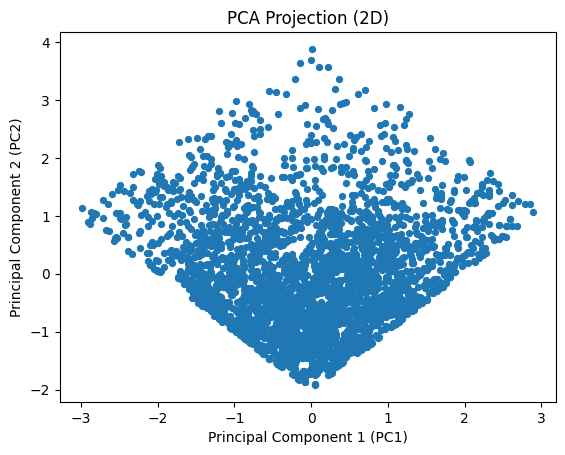

In [23]:
plt.figure()
plt.scatter(pca_df["PC1"], pca_df["PC2"], s=18)
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.title("PCA Projection (2D)")
plt.show()

### Extra (strong for grading): Feature contribution to PC1/PC2

This shows which original features contribute most to each principal component.  
Large magnitude = stronger contribution (positive or negative direction).


In [24]:
loadings = pd.DataFrame(
    pca.components_,
    columns=numeric_cols,
    index=["PC1", "PC2"]
).T

# Show biggest contributors for each PC
top_pc1 = loadings["PC1"].abs().sort_values(ascending=False).head(10)
top_pc2 = loadings["PC2"].abs().sort_values(ascending=False).head(10)

loadings.head(), top_pc1, top_pc2


(                    PC1       PC2
 Amount         0.707107  0.707107
 Boxes Shipped -0.707107  0.707107,
 Amount           0.707107
 Boxes Shipped    0.707107
 Name: PC1, dtype: float64,
 Boxes Shipped    0.707107
 Amount           0.707107
 Name: PC2, dtype: float64)